In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
file_path = "../dataset/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="utf-8"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

Number of rows: 5572
Number of columns: 2

Column names:
['label', 'message']

Data types:
label      str
message    str
dtype: object

First 5 records:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 403


In [10]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
label      0
message    0
dtype: int64


In [12]:
df = df.dropna()

print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (5169, 2)


In [13]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


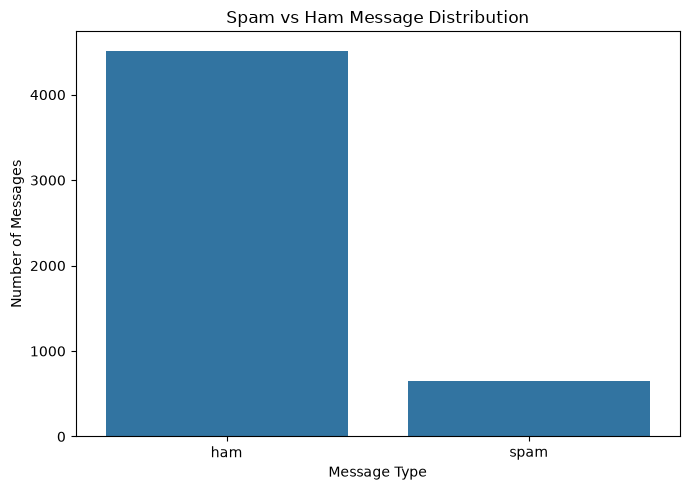

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()

plt.show()

In [15]:
df["message_length"] = df["message"].apply(len)

df["word_count"] = df["message"].apply(
    lambda x: len(x.split())
)

df["digit_count"] = df["message"].apply(
    lambda x: sum(c.isdigit() for c in x)
)

df["uppercase_count"] = df["message"].apply(
    lambda x: sum(c.isupper() for c in x)
)

df["special_character_count"] = df["message"].apply(
    lambda x: sum(
        not c.isalnum() and not c.isspace()
        for c in x
    )
)

df.head()

,label,message,message_length,word_count,digit_count,uppercase_count,special_character_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0,3,9
1,ham,Ok lar... Joking wif u oni...,29,6,0,2,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,25,10,6
3,ham,U dun say so early hor... U c already then say...,49,11,0,2,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,2,2


In [16]:
df[
    [
        "message_length",
        "word_count",
        "digit_count",
        "uppercase_count",
        "special_character_count"
    ]
].describe()

,message_length,word_count,digit_count,uppercase_count,special_character_count
count,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000
mean,79.344554,15.439930,2.215902,5.407816,4.135423
std,58.437457,11.117073,6.031250,11.778663,4.447953
min,2.000000,1.000000,0.000000,0.000000,0.000000
25%,36.000000,7.000000,0.000000,1.000000,2.000000
50%,61.000000,12.000000,0.000000,2.000000,3.000000
75%,119.000000,22.000000,1.000000,4.000000,6.000000
max,910.000000,171.000000,47.000000,138.000000,133.000000


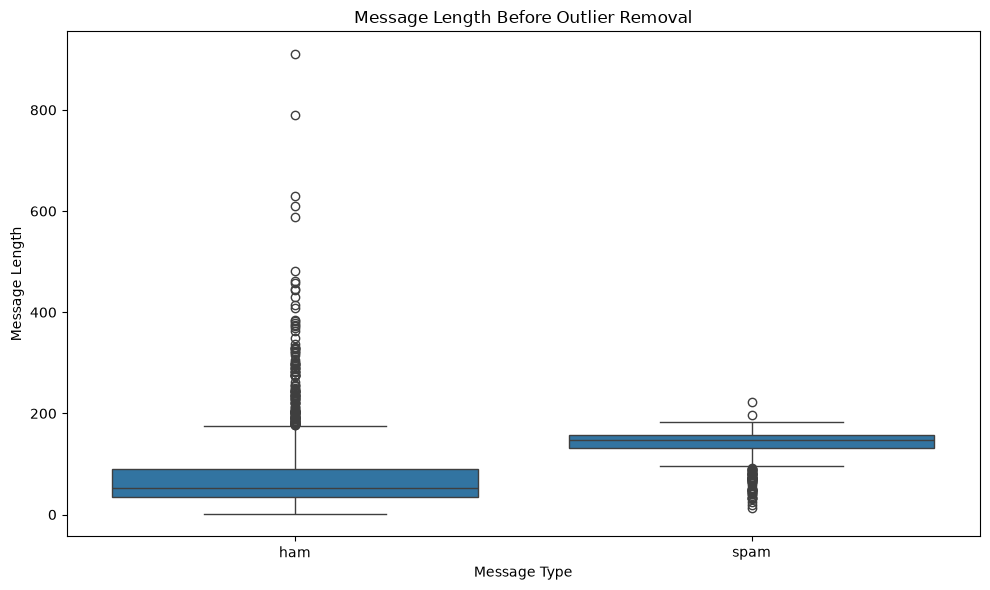

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="label",
    y="message_length"
)

plt.title("Message Length Before Outlier Removal")
plt.xlabel("Message Type")
plt.ylabel("Message Length")

plt.tight_layout()

plt.show()

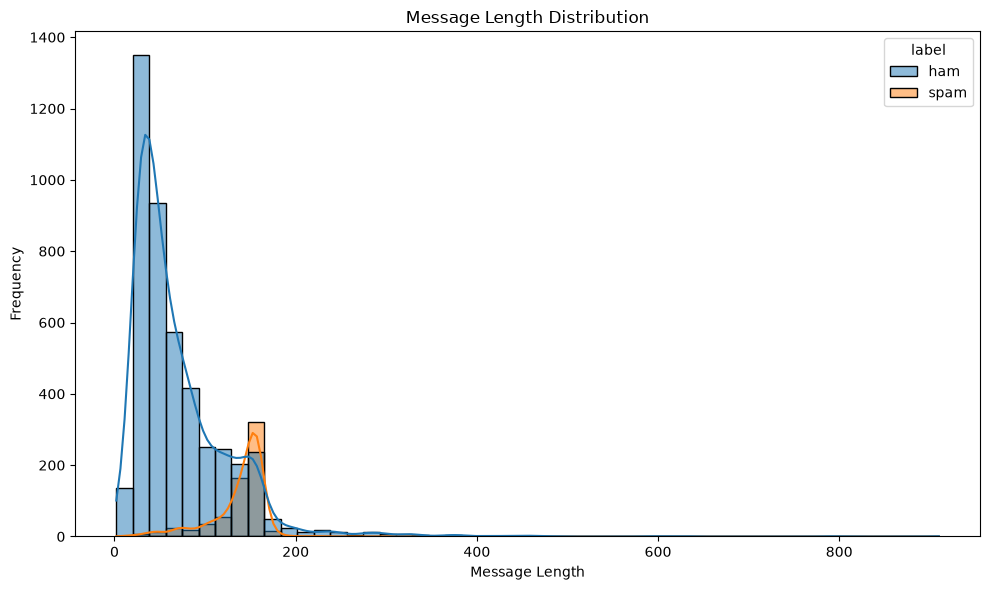

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

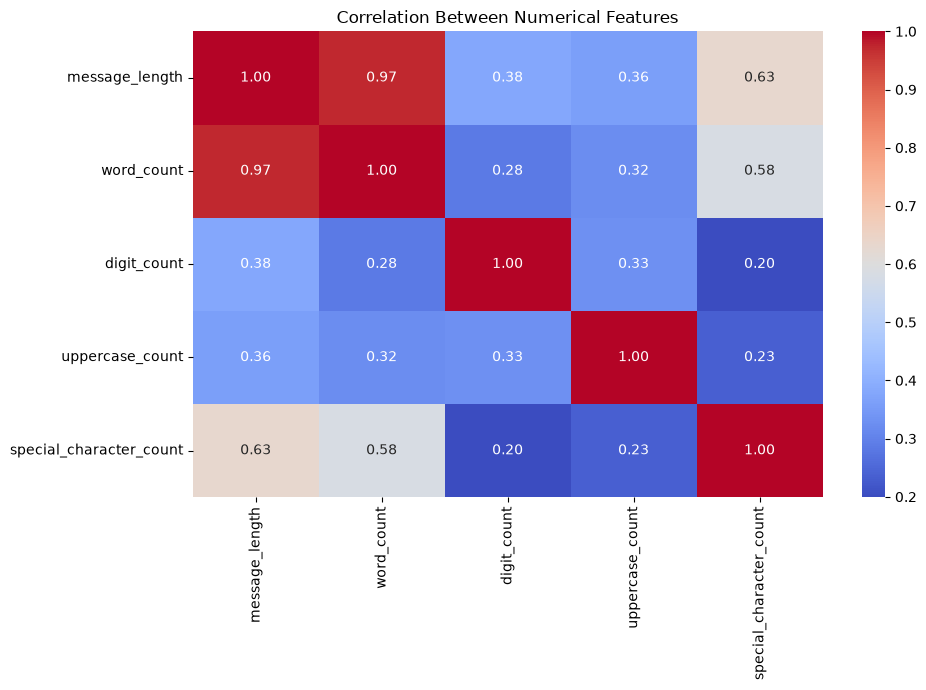

In [19]:
numeric_columns = [
    "message_length",
    "word_count",
    "digit_count",
    "uppercase_count",
    "special_character_count"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.tight_layout()

plt.show()

In [20]:
df.shape

(5169, 7)

In [21]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [22]:
df["label_numeric"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df[["label", "label_numeric"]].head()

,label,label_numeric
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [23]:
X = df["message"]
y = df["label_numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [24]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7414)
Testing TF-IDF shape: (1034, 7414)


In [25]:
model_before = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_before.fit(
    X_train_tfidf,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [26]:
y_pred_before = model_before.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [27]:
accuracy_before = accuracy_score(
    y_test,
    y_pred_before
)

precision_before = precision_score(
    y_test,
    y_pred_before
)

recall_before = recall_score(
    y_test,
    y_pred_before
)

f1_before = f1_score(
    y_test,
    y_pred_before
)

print("MODEL BEFORE OUTLIER REMOVAL")
print("=" * 40)

print(f"Accuracy : {accuracy_before:.4f}")
print(f"Precision: {precision_before:.4f}")
print(f"Recall   : {recall_before:.4f}")
print(f"F1 Score : {f1_before:.4f}")

MODEL BEFORE OUTLIER REMOVAL
Accuracy : 0.9565
Precision: 0.9778
Recall   : 0.6718
F1 Score : 0.7964


In [28]:
print(
    classification_report(
        y_test,
        y_pred_before,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.98      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



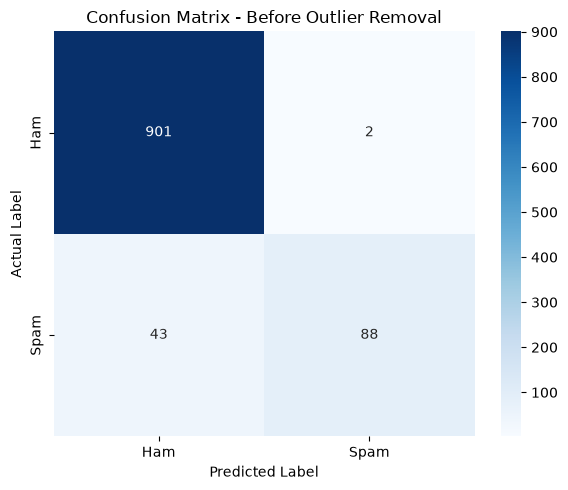

In [29]:
cm_before = confusion_matrix(
    y_test,
    y_pred_before
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Before Outlier Removal")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

In [31]:
outlier_features = [
    "message_length",
    "word_count",
    "digit_count",
    "uppercase_count",
    "special_character_count"
]

outlier_mask = pd.Series(False, index=df.index)

for column in outlier_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column_outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_mask = outlier_mask | column_outliers

    print(f"\n{column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Outliers: {column_outliers.sum()}")


message_length
Q1: 36.00
Q3: 119.00
IQR: 83.00
Lower Bound: -88.50
Upper Bound: 243.50
Outliers: 64

word_count
Q1: 7.00
Q3: 22.00
IQR: 15.00
Lower Bound: -15.50
Upper Bound: 44.50
Outliers: 69

digit_count
Q1: 0.00
Q3: 1.00
IQR: 1.00
Lower Bound: -1.50
Upper Bound: 2.50
Outliers: 710

uppercase_count
Q1: 1.00
Q3: 4.00
IQR: 3.00
Lower Bound: -3.50
Upper Bound: 8.50
Outliers: 711

special_character_count
Q1: 2.00
Q3: 6.00
IQR: 4.00
Lower Bound: -4.00
Upper Bound: 12.00
Outliers: 199


In [32]:
print("Total outliers detected:", outlier_mask.sum())
print(
    "Percentage of dataset identified as outliers:",
    f"{(outlier_mask.sum() / len(df)) * 100:.2f}%"
)

Total outliers detected: 1089
Percentage of dataset identified as outliers: 21.07%


In [33]:
df_clean = df[~outlier_mask].copy()

print("Original dataset:", len(df))
print("Outliers removed:", outlier_mask.sum())
print("Dataset after outlier removal:", len(df_clean))

Original dataset: 5169
Outliers removed: 1089
Dataset after outlier removal: 4080


In [34]:
print("\nClass distribution after outlier removal:")
print(df_clean["label"].value_counts())


Class distribution after outlier removal:
label
ham     4044
spam      36
Name: count, dtype: int64


In [35]:
# Detect message-length outliers separately for Ham and Spam

outlier_mask_length = pd.Series(False, index=df.index)

for label in ["ham", "spam"]:
    
    class_data = df[df["label"] == label]["message_length"]
    
    Q1 = class_data.quantile(0.25)
    Q3 = class_data.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    class_outliers = (
        (df["label"] == label) &
        (
            (df["message_length"] < lower_bound) |
            (df["message_length"] > upper_bound)
        )
    )
    
    outlier_mask_length = outlier_mask_length | class_outliers
    
    print(f"\nClass: {label}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Outliers: {class_outliers.sum()}")


Class: ham
Q1: 34.00
Q3: 91.00
IQR: 57.00
Lower Bound: -51.50
Upper Bound: 176.50
Outliers: 139

Class: spam
Q1: 132.00
Q3: 157.00
IQR: 25.00
Lower Bound: 94.50
Upper Bound: 194.50
Outliers: 65


In [36]:
print("\nTOTAL MESSAGE-LENGTH OUTLIERS:", outlier_mask_length.sum())
print(
    "Percentage:",
    f"{(outlier_mask_length.sum() / len(df)) * 100:.2f}%"
)


TOTAL MESSAGE-LENGTH OUTLIERS: 204
Percentage: 3.95%


In [37]:
print("Outliers by class:")
print(df.loc[outlier_mask_length, "label"].value_counts())

Outliers by class:
label
ham     139
spam     65
Name: count, dtype: int64


In [38]:
df_clean = df[~outlier_mask_length].copy()

print("Original dataset:", len(df))
print("Outliers removed:", outlier_mask_length.sum())
print("Dataset after outlier removal:", len(df_clean))

print("\nClass distribution after outlier removal:")
print(df_clean["label"].value_counts())

Original dataset: 5169
Outliers removed: 204
Dataset after outlier removal: 4965

Class distribution after outlier removal:
label
ham     4377
spam     588
Name: count, dtype: int64


In [39]:
X_after = df_clean["message"]
y_after = df_clean["label_numeric"]

X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(
    X_after,
    y_after,
    test_size=0.2,
    random_state=42,
    stratify=y_after
)

print("Training samples:", len(X_train_after))
print("Testing samples:", len(X_test_after))

Training samples: 3972
Testing samples: 993


In [40]:
vectorizer_after = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_after_tfidf = vectorizer_after.fit_transform(X_train_after)

X_test_after_tfidf = vectorizer_after.transform(X_test_after)

print("Training TF-IDF shape:", X_train_after_tfidf.shape)
print("Testing TF-IDF shape:", X_test_after_tfidf.shape)

Training TF-IDF shape: (3972, 6890)
Testing TF-IDF shape: (993, 6890)


In [41]:
model_after = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_after.fit(
    X_train_after_tfidf,
    y_train_after
)

print("Model trained successfully!")

Model trained successfully!


In [42]:
y_pred_after = model_after.predict(
    X_test_after_tfidf
)

print("Predictions completed!")

Predictions completed!


In [43]:
accuracy_after = accuracy_score(
    y_test_after,
    y_pred_after
)

precision_after = precision_score(
    y_test_after,
    y_pred_after
)

recall_after = recall_score(
    y_test_after,
    y_pred_after
)

f1_after = f1_score(
    y_test_after,
    y_pred_after
)

print("MODEL AFTER OUTLIER REMOVAL")
print("=" * 40)

print(f"Accuracy : {accuracy_after:.4f}")
print(f"Precision: {precision_after:.4f}")
print(f"Recall   : {recall_after:.4f}")
print(f"F1 Score : {f1_after:.4f}")

MODEL AFTER OUTLIER REMOVAL
Accuracy : 0.9637
Precision: 0.9767
Recall   : 0.7119
F1 Score : 0.8235


In [44]:
print(
    classification_report(
        y_test_after,
        y_pred_after,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       875
        Spam       0.98      0.71      0.82       118

    accuracy                           0.96       993
   macro avg       0.97      0.85      0.90       993
weighted avg       0.96      0.96      0.96       993



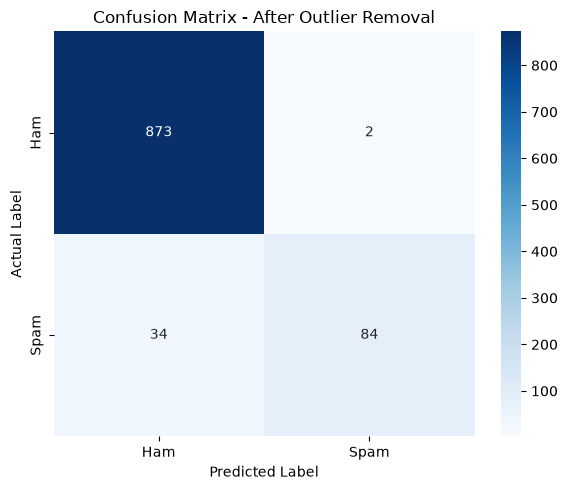

In [45]:
cm_after = confusion_matrix(
    y_test_after,
    y_pred_after
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - After Outlier Removal")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

In [46]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    
    "Before Outlier Removal": [
        accuracy_before,
        precision_before,
        recall_before,
        f1_before
    ],
    
    "After Outlier Removal": [
        accuracy_after,
        precision_after,
        recall_after,
        f1_after
    ]
})

comparison

,Metric,Before Outlier Removal,After Outlier Removal
0,Accuracy,0.956480,0.963746
1,Precision,0.977778,0.976744
2,Recall,0.671756,0.711864
3,F1 Score,0.796380,0.823529


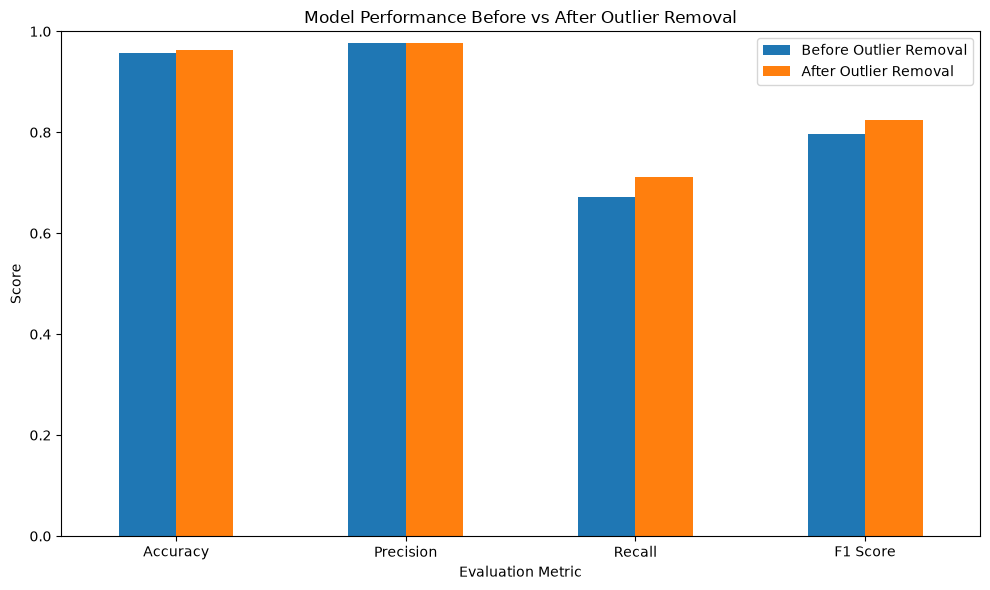

In [47]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Before vs After Outlier Removal")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()

plt.show()

In [48]:
dataset_comparison = pd.DataFrame({
    "Stage": [
        "Before Outlier Removal",
        "After Outlier Removal"
    ],
    "Total Messages": [
        len(df),
        len(df_clean)
    ],
    "Ham": [
        (df["label"] == "ham").sum(),
        (df_clean["label"] == "ham").sum()
    ],
    "Spam": [
        (df["label"] == "spam").sum(),
        (df_clean["label"] == "spam").sum()
    ]
})

dataset_comparison

,Stage,Total Messages,Ham,Spam
0,Before Outlier Removal,5169,4516,653
1,After Outlier Removal,4965,4377,588


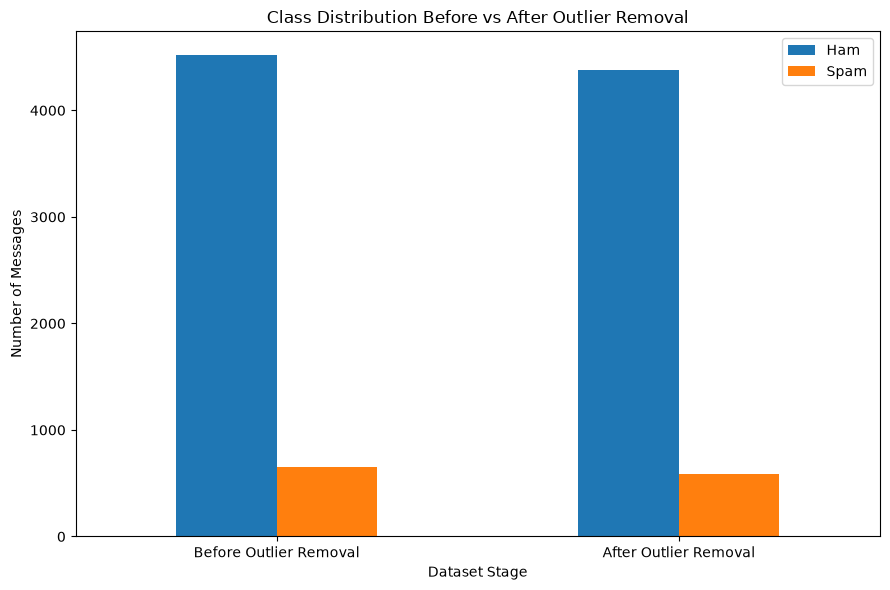

In [49]:
dataset_comparison.set_index("Stage")[["Ham", "Spam"]].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Class Distribution Before vs After Outlier Removal")
plt.xlabel("Dataset Stage")
plt.ylabel("Number of Messages")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

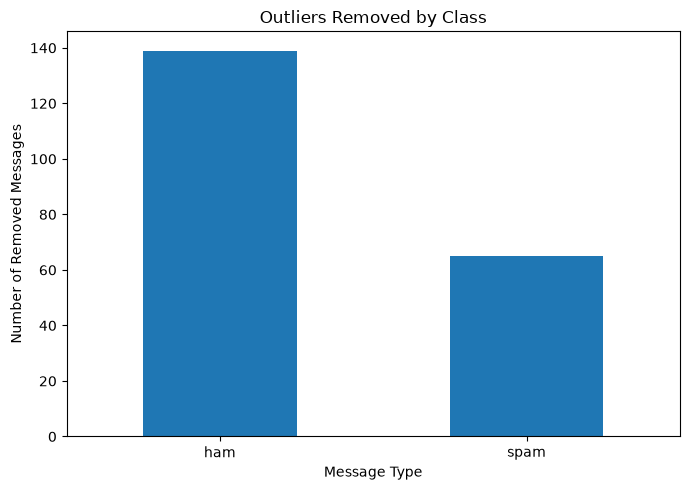

In [50]:
removed_by_class = df.loc[outlier_mask_length, "label"].value_counts()

plt.figure(figsize=(7, 5))

removed_by_class.plot(kind="bar")

plt.title("Outliers Removed by Class")
plt.xlabel("Message Type")
plt.ylabel("Number of Removed Messages")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

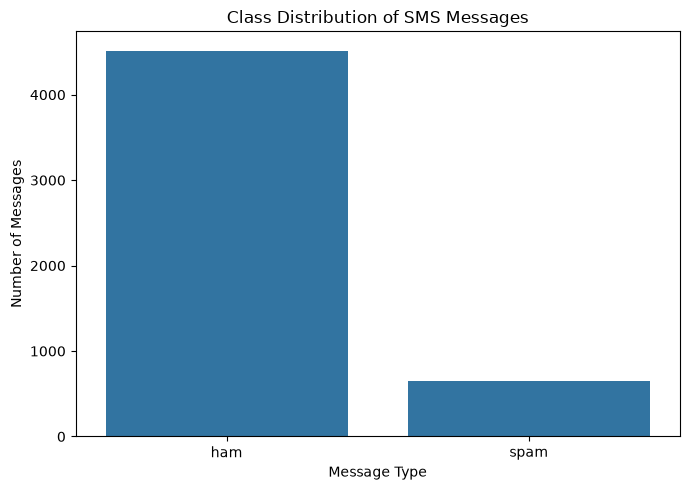

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Class Distribution of SMS Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()

plt.savefig("../visualizations/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

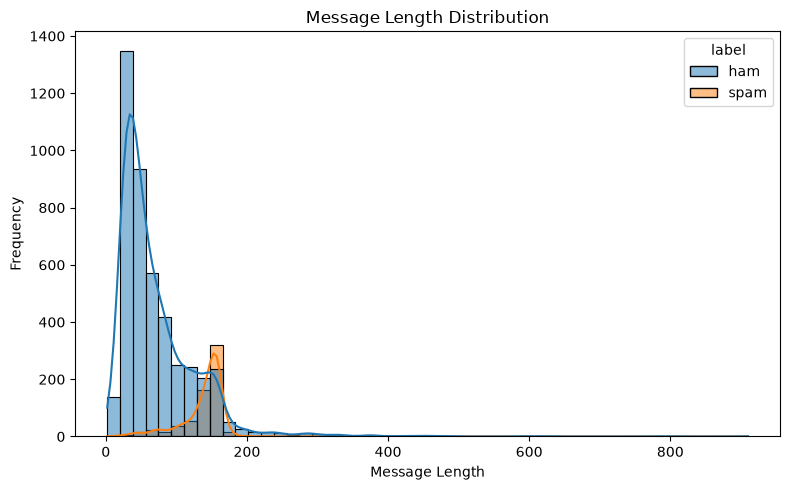

In [52]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/message_length_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

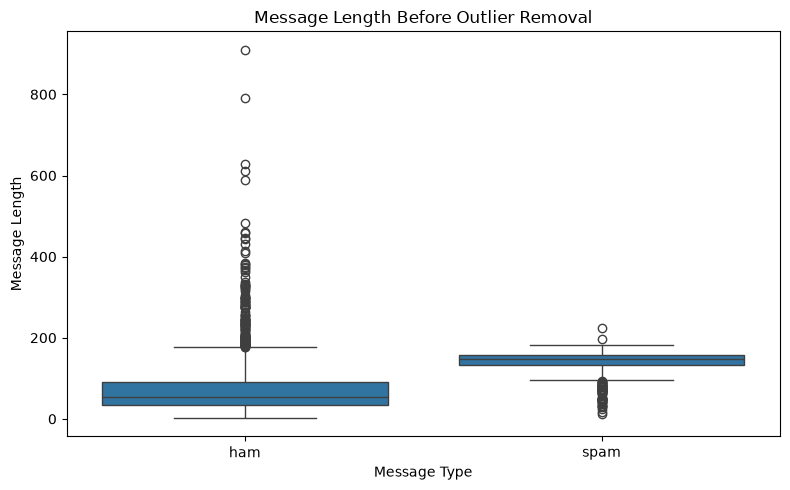

In [53]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="message_length"
)

plt.title("Message Length Before Outlier Removal")
plt.xlabel("Message Type")
plt.ylabel("Message Length")

plt.tight_layout()

plt.savefig("../visualizations/boxplot_before.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

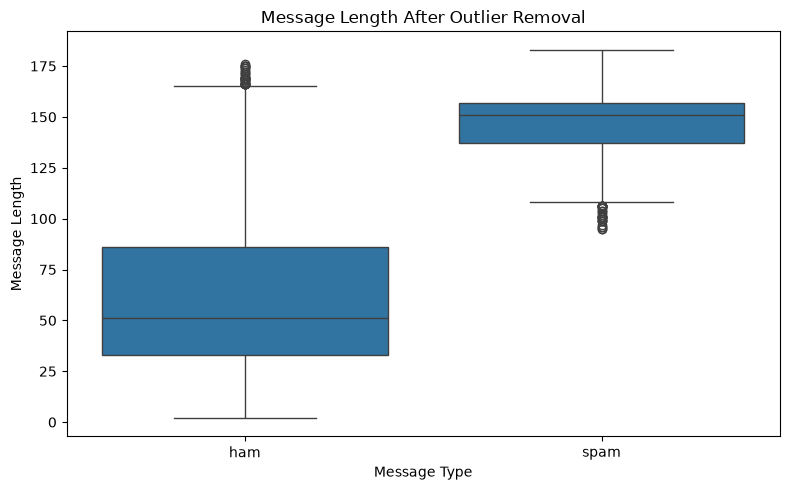

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="message_length"
)

plt.title("Message Length After Outlier Removal")
plt.xlabel("Message Type")
plt.ylabel("Message Length")

plt.tight_layout()

plt.savefig("../visualizations/boxplot_after.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [58]:
# Generate predictions for the BEFORE outlier removal model

y_pred_before = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

NameError: name 'model' is not defined

In [59]:
# Prepare data BEFORE outlier removal

X_before = df["message"]
y_before = df["label_numeric"]

X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(
    X_before,
    y_before,
    test_size=0.2,
    random_state=42,
    stratify=y_before
)

print("Training samples:", len(X_train_before))
print("Testing samples:", len(X_test_before))

Training samples: 4135
Testing samples: 1034


In [60]:
vectorizer_before = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_before_tfidf = vectorizer_before.fit_transform(
    X_train_before
)

X_test_before_tfidf = vectorizer_before.transform(
    X_test_before
)

print("Training TF-IDF shape:", X_train_before_tfidf.shape)
print("Testing TF-IDF shape:", X_test_before_tfidf.shape)

Training TF-IDF shape: (4135, 7414)
Testing TF-IDF shape: (1034, 7414)


In [61]:
model_before = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_before.fit(
    X_train_before_tfidf,
    y_train_before
)

print("Before-outlier model trained successfully!")

Before-outlier model trained successfully!


In [62]:
y_pred_before = model_before.predict(
    X_test_before_tfidf
)

print("Before-outlier predictions generated successfully!")

Before-outlier predictions generated successfully!


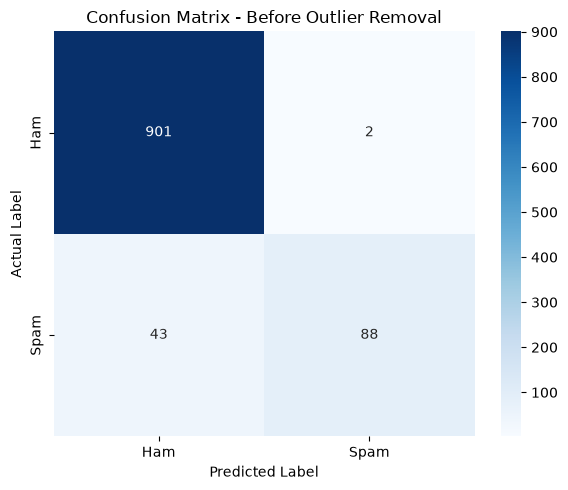

In [63]:
cm_before = confusion_matrix(
    y_test_before,
    y_pred_before
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Before Outlier Removal")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "../visualizations/confusion_matrix_before.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

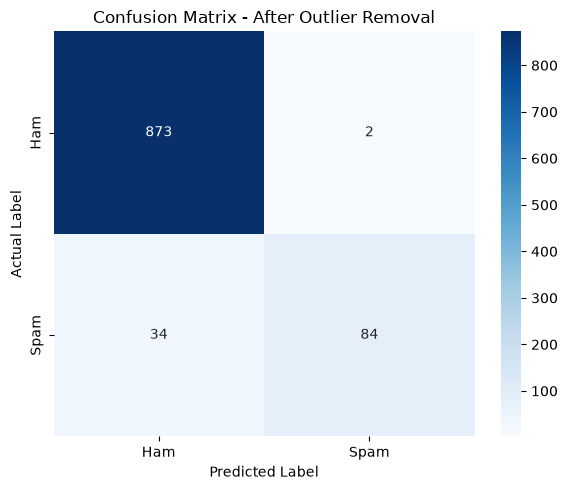

In [64]:
cm_after = confusion_matrix(
    y_test_after,
    y_pred_after
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - After Outlier Removal")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "../visualizations/confusion_matrix_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

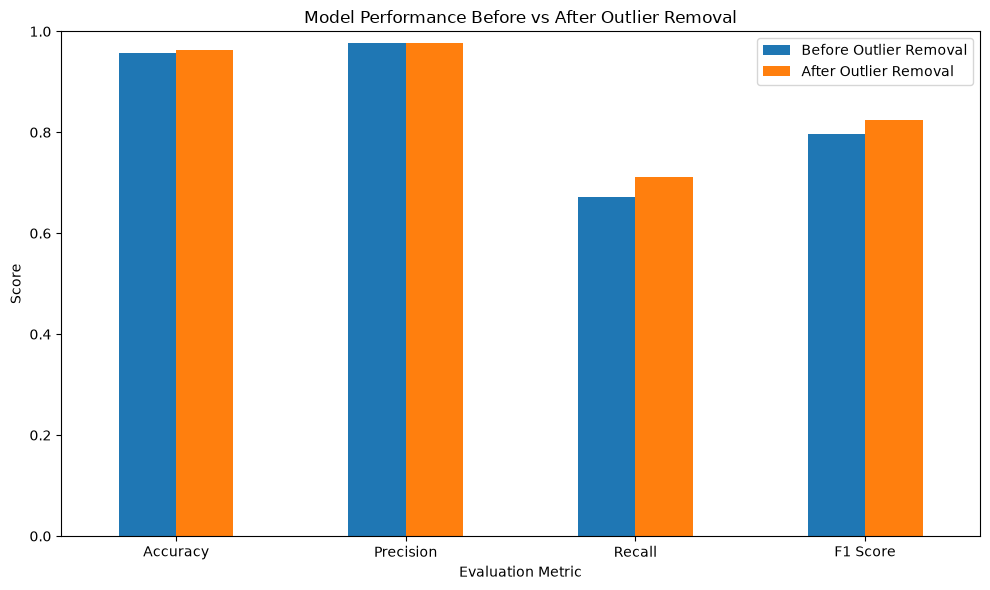

In [65]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Before vs After Outlier Removal")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../visualizations/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

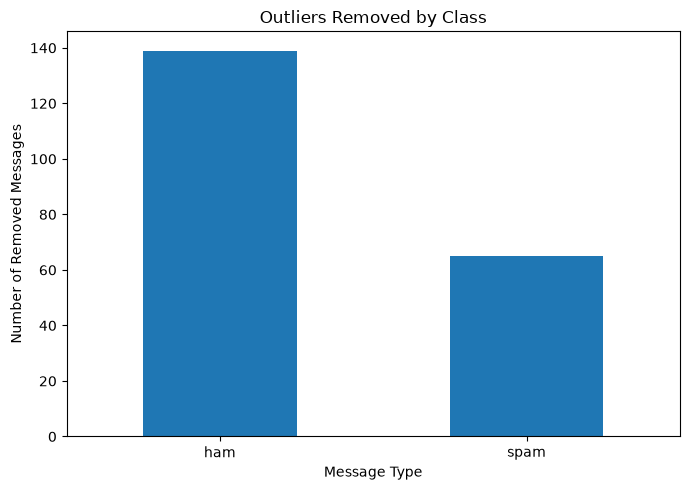

In [66]:
removed_by_class = df.loc[
    outlier_mask_length,
    "label"
].value_counts()

plt.figure(figsize=(7, 5))

removed_by_class.plot(kind="bar")

plt.title("Outliers Removed by Class")
plt.xlabel("Message Type")
plt.ylabel("Number of Removed Messages")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/outliers_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()